
link do relatorio (ir atualizando conforme projeto anda e depois só revisar):


https://www.overleaf.com/9585645646wvrcmtjhykkb#925050



dataset que será usado:

https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets/data?select=b2w.csv

# Importações e configurações

In [ ]:
import pandas as pd
import os
from google.colab import userdata
import kagglehub


In [ ]:
from matplotlib import pyplot as plt


In [ ]:
import seaborn as sns


# 1. Conjunto de dados


1.1. Baixe o dataset, carregue as amostras de treino e teste em um dataframe.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("fredericods/ptbr-sentiment-analysis-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ptbr-sentiment-analysis-datasets' dataset.
Path to dataset files: /kaggle/input/ptbr-sentiment-analysis-datasets


In [ ]:
path_real = path+"/b2w.csv"
data = pd.read_csv(path_real)
data.head()

,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,11955,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbati...,"['bem', 'macio', 'felpudo', 'recomendo', 'prec...",1.0,4,1,1
1,35478,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e ...,"['produto', 'excepcional', 'recomendo', 'inova...",1.0,5,1,1
2,122760,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,"['recebi', 'produto', 'antes', 'do', 'prazo', ...",0.0,1,1,1
3,17114,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,"['bom', 'custo', 'beneficio', 'adequado', 'par...",1.0,5,1,1
4,19112,Além de higiênico tem o tamanho ideal. Só falt...,alem de higienico tem o tamanho ideal. so falt...,"['alem', 'de', 'higienico', 'tem', 'tamanho', ...",NaN,3,-1,1


# 2. Análise Exploratória

In [ ]:
print("Total de instâncias: ")
data.shape

Total de instâncias: 


(132373, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   original_index         132373 non-null  int64  
 1   review_text            132373 non-null  object 
 2   review_text_processed  132373 non-null  object 
 3   review_text_tokenized  132373 non-null  object 
 4   polarity               116058 non-null  float64
 5   rating                 132373 non-null  int64  
 6   kfold_polarity         132373 non-null  int64  
 7   kfold_rating           132373 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 8.1+ MB


In [ ]:
print("Distribuição entre classes: ")

# consideraremos as classes o rating e a polarity
data['polarity'].value_counts()

Distribuição entre classes: 


,count
polarity,
1.0,80300
0.0,35758


In [ ]:
data['rating'].value_counts()


,count
rating,
5,47955
4,32345
1,27369
3,16315
2,8389


In [ ]:
print("Presença de classes desbalanceadas: ")

# mostrar o gráfico de rating e polarity


Presença de classes desbalanceadas: 


/tmp/ipykernel_1074/3030356146.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=data, palette='viridis')


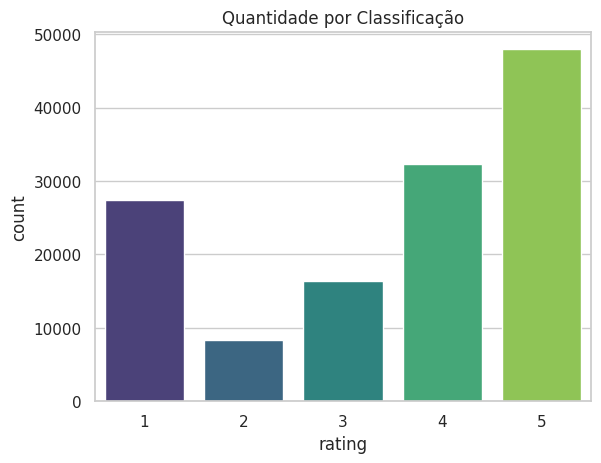

In [ ]:
sns.countplot(x='rating', data=data, palette='viridis')

plt.title('Quantidade por Classificação')
plt.show()

In [ ]:
import numpy as np

# para treinamento em relação às classes, vamos dividi-las em positivo e negativo
# negativo indo de 1 a 2
# positivo indo de 3 a 5
# além disso, precisamos ter o mesmo tanto de cada classe de polaridade

# inicializa a coluna 'sentiment_class' com np.nan para lidar com ratings fora do esperado ou NaN
data['sentiment_class'] = np.nan

# usando df.loc para atribuição condicional
data.loc[data['rating'] <= 2, 'sentiment_class'] = 'negativo'
data.loc[(data['rating'] >= 3) & (data['rating'] <= 5), 'sentiment_class'] = 'positivo'

print(data['sentiment_class'].value_counts())

sentiment_class
positivo    96615
negativo    35758
Name: count, dtype: int64


/tmp/ipykernel_1074/3264854471.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'negativo' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[data['rating'] <= 2, 'sentiment_class'] = 'negativo'


/tmp/ipykernel_1074/758180312.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_class', data=data, palette="viridis")


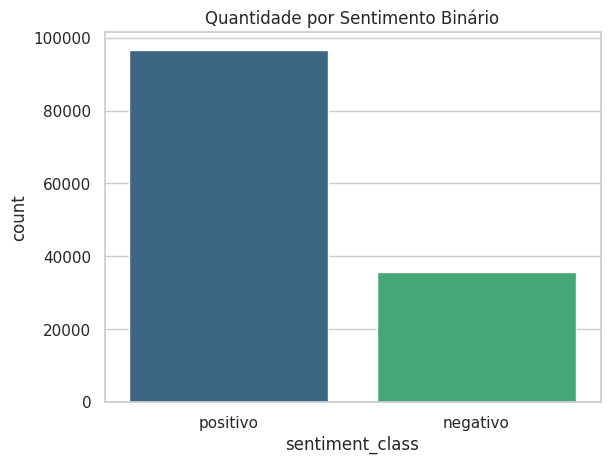

In [ ]:
sns.countplot(x='sentiment_class', data=data, palette="viridis")
plt.title("Quantidade por Sentimento Binário")
plt.show()

/tmp/ipykernel_1074/2183556204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='polarity', data=data, palette="viridis")


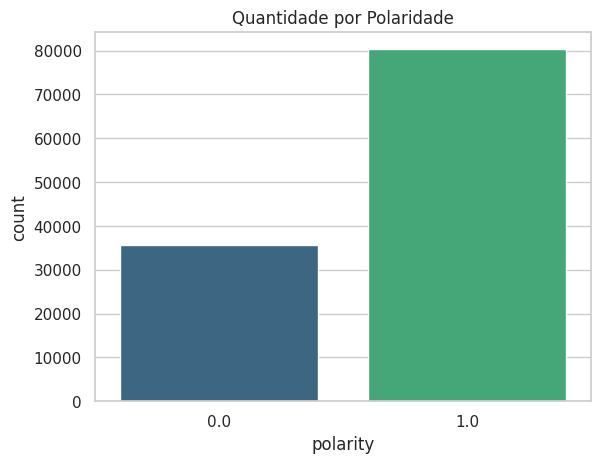

In [ ]:
sns.countplot(x='polarity', data=data, palette="viridis")
plt.title('Quantidade por Polaridade')
plt.show()

In [ ]:
print("Tamanho médio dos textos: ")

tamanho = 0
for text in data['review_text']:
  tamanho += len(text.split())

tam_rt = data['review_text'].count()

print(tamanho/tam_rt)

Tamanho médio dos textos: 
23.877837625497648


In [ ]:
# montar um dicionario de frequencia e printar as 20 primeiras
from collections import Counter
import ast

print("Palavras mais frequentes: ")

token_reviews = data['review_text_tokenized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

todas_palavras = [palavra for sublista in token_reviews for palavra in sublista]

frequencia_palavras = Counter(todas_palavras)

mais_comuns = frequencia_palavras.most_common(20)
for palavra, frequencia in mais_comuns:
    print(f"{palavra}: {frequencia}")




Palavras mais frequentes: 
de: 90117
produto: 74739
nao: 73223
que: 65774
muito: 53053
do: 43736
com: 43301
para: 34479
um: 34221
bom: 26428
da: 25945
recomendo: 25220
entrega: 24143
no: 23889
em: 23610
na: 19698
mas: 19537
uma: 19225
mais: 18980
bem: 17359


In [ ]:
# montar vocabulario

def converte_para_lista(txt):
  if isinstance(txt, str):
    return ast.literal_eval(txt)
  return txt

tokens_reais = data['review_text_tokenized'].apply(converte_para_lista)

vocabulario = set(todas_palavras)

print(f"vocabulário total: {len(vocabulario)} palavras")


vocabulário total: 51761 palavras


In [ ]:
print("Textos duplicados ou vazios: ")

vazios = data['review_text'].isnull().sum()

duplicados = data['review_text'].duplicated().sum()

print(f"Textos vazios: {vazios}")
print(f"Textos duplicados: {duplicados}")

Textos duplicados ou vazios: 
Textos vazios: 0
Textos duplicados: 2581


In [ ]:
print("Valores ausentes: ")

# verificar todos os textos e ver quais são "vazios"
n_valores_ausentes = 0

for texto in data['review_text_processed']:
  if texto == "." or texto == " ":
    n_valores_ausentes+=1
    n_valores_ausentes+=1
  elif len(texto.split()) < 2:
    print(texto)
  # else:
    # print(len(texto.split()))
# print(n_valores_ausentes)

# não existem valores ausentes, mas sim alguns textos que são apenas ruídos
# como sequência de pontos, "kkk", "xxx", etc.

Valores ausentes: 
................................................................................
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1
.................................................................................................................................................................................................................................................
perfeito..........................................
gostei................................................................................
....................................................................
bom....................................................................................................................................
ruiruiiiiiuiiiiiiiiiiiiiiiiiiiiiruiiiiiiiiiiiiiiii8iiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii
excelente!.....................................................
divertido.........................................................................
.............

In [ ]:
print("Exemplos reais de cada classe: ")

print("Exemplos da classe positivo: ")

# imprimir 20 exemplos

Exemplos reais de cada classe: 
Exemplos da classe positivo: 


In [ ]:
print("Exemplos da classe negativo: ")

# imprimir 20 exemplos

Exemplos da classe negativo: 


In [ ]:
print("")

# 2.2 Visualizações

Guilherme a unica maneira que eu decobri de fazer os histogramas é indo para depois da parte de tratamento. Nao sei se é a melhor, mas achei melhor ir fazendo logo, se der certo nós ajeita os índices dps e se não der nós se mata

In [ ]:
# histograma de tamanho dos textos

In [ ]:
# nuvem de palavras

In [ ]:
# tabela resumo

#3.1 Tratamento dos Dados

In [ ]:
# remover dados nulos
# nan
# ausentes

In [ ]:
data.isnull().sum()

,0
original_index,0
review_text,0
review_text_processed,0
review_text_tokenized,0
polarity,16315
rating,0
kfold_polarity,0
kfold_rating,0
sentiment_class,0


In [ ]:
# reaproveitei a limpeza que tu tinha feito e so coloquei aqui (ass gui)

data_sem_duplicata = data.drop_duplicates(subset=['review_text'])
data_limpo = data_sem_duplicata.dropna()

print(f"Tamanho apos limpeza: {len(data_limpo)}")

Tamanho apos limpeza: 113647


In [ ]:
data_limpo.isnull().sum()

,0
original_index,0
review_text,0
review_text_processed,0
review_text_tokenized,0
polarity,0
rating,0
kfold_polarity,0
kfold_rating,0
sentiment_class,0


In [ ]:
# acho que aqui já podemos equilibrar as classes também,
# pegando a mesma quantidade de cada

# 3.2 Pré procesamento

In [ ]:
# o dataframe já tem uma coluna com os dados tokenizados, mas optamos por tratar eles do zero
# depois iremos fazer uma pequena comparação com a coluna dos dados tokenizados nativa

### 3.2.1. Limpeza de nulos e duplicados

In [ ]:
print(f'tamanho inicial: {len(data)}')

data = data.dropna(subset=['review_text'])
data = data.drop_duplicates(subset=['review_text'], keep='first')

print(f'tamanho final: {len(data)}')

tamanho inicial: 132373
tamanho final: 129792


### 3.2.2. Lowercasing e remoção de pontuação

In [ ]:
import re

#lowecasing:
data['review_text'] = data['review_text'].str.lower()

#removendo pontuação e garantindo separação de palavras
def limpeza(texto):
  # Substitui qualquer caractere que não seja letra (incluindo acentuadas), número ou espaço por um espaço
  texto = re.sub(r'[^a-zA-Z0-9\s\u00C0-\u017F]', ' ', texto, flags=re.UNICODE)
  # Remove espaços extras que podem resultar da substituição de múltiplas pontuações
  return re.sub(r'\s+', ' ', texto).strip()

data['review_text'] = data['review_text'].apply(limpeza)

print(f'Exemplo apos lowecasing e limpeza: {data['review_text'].head()}')

Exemplo apos lowecasing e limpeza: 0    bem macio e felpudorecomendo preço imbatível e...
1    produto excepcional recomendo inovador e gosto...
2    recebi o produto antes do prazo mas veio com d...
3    bom custo beneficio adequado para pessoas que ...
4    além de higiênico tem o tamanho ideal só falto...
Name: review_text, dtype: object


### #3.2.3. Tokenização

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

data['tokens'] = data['review_text'].apply(word_tokenize)
print('resultado: ')
print(data[['review_text', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


resultado: 
                                         review_text  \
0  bem macio e felpudorecomendo preço imbatível e...   
1  produto excepcional recomendo inovador e gosto...   
2  recebi o produto antes do prazo mas veio com d...   
3  bom custo beneficio adequado para pessoas que ...   
4  além de higiênico tem o tamanho ideal só falto...   

                                              tokens  
0  [bem, macio, e, felpudorecomendo, preço, imbat...  
1  [produto, excepcional, recomendo, inovador, e,...  
2  [recebi, o, produto, antes, do, prazo, mas, ve...  
3  [bom, custo, beneficio, adequado, para, pessoa...  
4  [além, de, higiênico, tem, o, tamanho, ideal, ...  


### #3.2.4. stopwords

In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

palavras_irre = set(stopwords.words('portuguese'))

def filtra(lista):
  return [palavra for palavra in lista if palavra not in palavras_irre]

data['tokens'] = data['tokens'].apply(filtra)
print('resultado: ')
print(data[['review_text', 'tokens']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


resultado: 
                                         review_text  \
0  bem macio e felpudorecomendo preço imbatível e...   
1  produto excepcional recomendo inovador e gosto...   
2  recebi o produto antes do prazo mas veio com d...   
3  bom custo beneficio adequado para pessoas que ...   
4  além de higiênico tem o tamanho ideal só falto...   

                                              tokens  
0  [bem, macio, felpudorecomendo, preço, imbatíve...  
1  [produto, excepcional, recomendo, inovador, go...  
2  [recebi, produto, antes, prazo, veio, defeito,...  
3  [bom, custo, beneficio, adequado, pessoas, faz...  
4  [além, higiênico, tamanho, ideal, faltou, colh...  


In [ ]:
n = 0
m = 0
p = 0
for token in data['tokens']:
  for t in token:
    if t == "produto":
      n+=1
    elif token=="produto ":
      m+=1
    elif token == " produto":
      p+=1
    elif token == "produto veio":
      p+=1
print(n, "produto sem espaco")
print(m, "produto com espaco no final")
print(p, "produto com espaco no comeco")



70902 produto sem espaco
0 produto com espaco no final
0 produto com espaco no comeco


### #3.2.5. Lematização

In [ ]:
from nltk import RSLPStemmer

nltk.download('rslp')

lema = RSLPStemmer()

def aplica(lista):
  return [lema.stem(palavra) for palavra in lista]

data['tokens_lem'] = data['tokens'].apply(aplica)
print('resultado: ')
print(data[['review_text', 'tokens_lem']].head())

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


resultado: 
                                         review_text  \
0  bem macio e felpudorecomendo preço imbatível e...   
1  produto excepcional recomendo inovador e gosto...   
2  recebi o produto antes do prazo mas veio com d...   
3  bom custo beneficio adequado para pessoas que ...   
4  além de higiênico tem o tamanho ideal só falto...   

                                          tokens_lem  
0  [bem, maci, felpudorecom, preç, imbat, entreg,...  
1           [produt, excepc, recom, inov, gost, ler]  
2  [receb, produt, ant, praz, vei, defeit, tr, us...  
3  [bom, cust, benefici, adequ, pesso, faz, uso, ...  
4  [além, higiên, tamanh, ideal, falt, colh, garf...  


## 3.2.1 TF-IDF

## 3.2.2

## 3.2.3

#?. Visualização

###?.1. Histograma #

count    129792.000000
mean         13.784640
std          13.071275
min           0.000000
25%           7.000000
50%          10.000000
75%          16.000000
max         617.000000
Name: tamanho_textos, dtype: float64


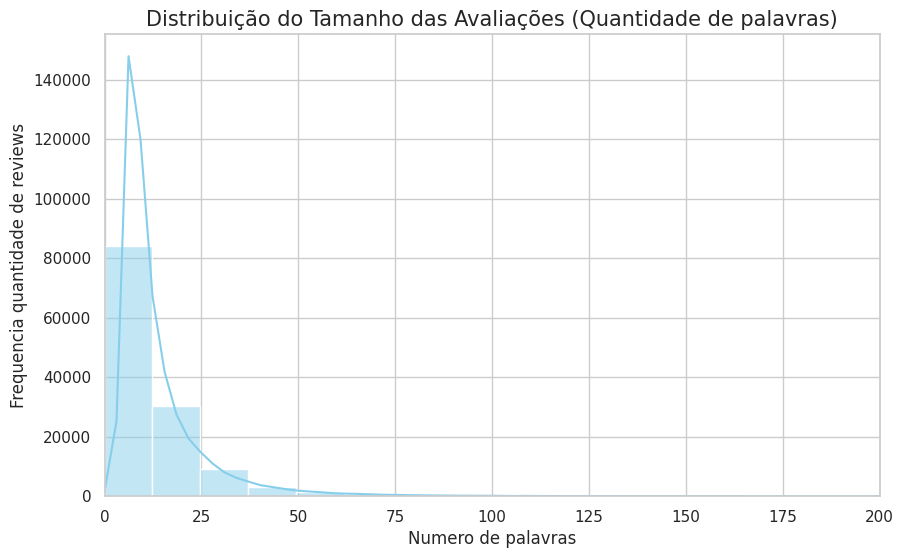

In [ ]:
data['tamanho_textos'] = data['tokens'].apply(len)
print(data['tamanho_textos'].describe())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data['tamanho_textos'], bins=50, kde=True, color='skyblue')

plt.title('Distribuição do Tamanho das Avaliações (Quantidade de palavras)', fontsize=15)
plt.xlabel('Numero de palavras', fontsize='12')
plt.ylabel('Frequencia quantidade de reviews', fontsize=12)

plt.xlim(0, 200)

plt.show()

###?.2. nuvem de palavras #

<function matplotlib.pyplot.show(close=None, block=None)>

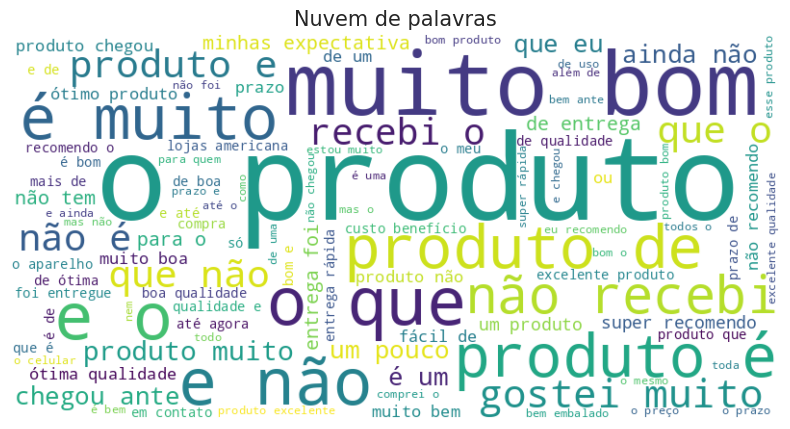

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_para_nuvem = ' '.join([' '.join(lista) for lista in data['tokens']])

nuvem = WordCloud(width=800,
                  height=400,
                  background_color='white',
                  colormap='viridis',
                  max_words=100).generate(texto_para_nuvem)

plt.figure(figsize=(10, 5))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de palavras', fontsize=15)
plt.show



In [ ]:
# tabela resumo



# 4. Treinamento do Modelo

## 4.1 Entrada Vetorial

# 5. Texto curto vs Texto Longo

#